## Fitting auditory single-unit activity

This tutorial will show you how to fit a model of a *specific unit* in the **CRCNS-AA1** dataset.

Let's start with some boilerplate imports.

In [1]:
import os
import wandb
import torch.utils

from deepSTRF.datasets.audio import CRCNS_AA1_Dataset
from deepSTRF.models.audio import StateNet
from deepSTRF.utils.training_pop import optimize_multiple_seeds

CUDA extension for structured kernels (Cauchy and Vandermonde multiplication) not found. Install by going to extensions/kernels/ and running `python setup.py install`, for improved speed and memory efficiency. Note that the kernel changed for state-spaces 4.0 and must be recompiled.
Falling back on slow Cauchy and Vandermonde kernel. Install at least one of pykeops or the CUDA extension for better speed and memory efficiency.


Let's check whether a GPU is available for PyTorch. 

In [2]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
print(f"\nSelected device: {device}\n")


Selected device: cpu



Define where you would like to work: save model checkpoints, etc.

In [3]:
root = '/home/ulysse/PycharmProjects/deepSTRF/deepSTRF/'  # change path manually

Let's now instanciate the dataset. For this, we need to define the path to the data (cf. CRCNS AA1 dataset setup instructions).
We'll target *one specific auditory area* called **MLd**.

In [4]:
# dataset
dataset_root = root + 'datasets/audio/CRCNS_AA1/data'
area = 'MLd'
dataset = CRCNS_AA1_Dataset(dataset_root, areas=(area,))
F = dataset.get_F()     # number of spectrogram frequency bands
N = dataset.get_N()     # total number of available neurons to fit in the dataset
print(f"Dataset of length {len(dataset)} stimuli presented to {N} cells")

Dataset of length 30 stimuli presented to 50 cells


Later in the tutorial, we'll narrow down our fitting process further down to *one specific unit*.

We also need to define a function to split the data into train, validation and test set, given our instanciated datasets.
As usual, we'll approximate a 70-10-20% ratio.

In [5]:
def data_split_func(dataset):
    train_set, valid_set, test_set = torch.utils.data.random_split(dataset, [21, 3, 6])
    return train_set, valid_set, test_set

Let's also define some training hyperparameters.

In [15]:
# optimization
seeds = list(range(1))  # only one seed here for the purpose of the demonstration
n_epochs_early_stop = 50
batch_size = 1    # CAUTION: must be 1 for this dataset, because stimulus-response sequences have variable durations
learning_rate = 0.001
weight_decay = 0.
criterion = torch.nn.MSELoss()

Now we can instanciate our model. Similar to above, we need to wrap this into a function which will be used at the beginning of the training process in different random seeds.
In this example, we'll go for a **StateNet** model (Rançon et al., 2025), which is fully time-recurrent model.

In [7]:
# prefiltering / parameterization (if applies) / model architecture hyperparameters
T = 1  # Temporal window size
prefilt_dict = {'type': 'AdapTrans', 'dt': 10.0, 'min_freq': 500, 'max_freq': 20000, 'scale': 'mel'}
param_dict = {'type': 'DCLS', 'num_gauss': 10}
def model_init_fn():
    """ change it as you like """
    # model = Linear(n_frequency_bands=F, temporal_window_size=T, out_neurons=N, prefiltering=prefilt_dict, parameterization=param_dict)
    # model = LinearNonlinear(n_frequency_bands=49, temporal_window_size=T, prefiltering=prefilt_dict, parameterization=param_dict)
    # model = NetworkReceptiveField(n_frequency_bands=49, temporal_window_size=T, n_hidden=20, prefiltering=prefilt_dict, parameterization=param_dict)
    # model = DNet(n_frequency_bands=F, temporal_window_size=T, n_hidden=20, init_tau=2., prefiltering=prefilt_dict, parameterization=param_dict)
    # model = ConvNet2D(n_frequency_bands=F, kernel_size=(3, 7), c_hidden=10, n_hidden=90, out_neurons=N, prefiltering=None)
    model = StateNet(n_frequency_bands=32, temporal_window_size=T, kernel_size=7, stride=3, hidden_channels=7, rnn_type='GRU', out_neurons=1)
    model = model.to(device)
    return model
net = model_init_fn()
print(net)

StateNet(
  (encoder_layers): Sequential(
    (0): LocallyConnected1d(
      (unfold): Unfold(kernel_size=(7, 1), dilation=1, padding=0, stride=3)
      (fold): Fold(output_size=(9, 1), kernel_size=(1, 1), dilation=1, padding=0, stride=1)
    )
    (1): BatchNorm1d(7, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Sigmoid()
  )
  (rnn): GRU(63, 63, batch_first=True)
  (fc): Linear(in_features=63, out_features=1, bias=True)
)


Log some hyperparameter values about the run on wandb; feel free to adapt it to your liking.

In [8]:
# Weights & Biases logging
os.environ["WANDB_MODE"] = "offline"  # comment out for online logging
project_name = 'deepSTRF'
entity_name = 'urancon'
config = {
    "seeds": seeds,
    "temporal_window_size": T,
    "learning_rate": learning_rate,
    "weight_decay": weight_decay,
    "model": net.__class__.__name__,
    "Nb of parameters": net.count_trainable_params(),
    "Dataset": dataset.__class__.__name__
}
wandb.init(project=project_name, entity=entity_name, config=config)
print(f"Model: {net.__class__.__name__}, # params: {net.count_trainable_params()}")

Model: StateNet, # params: 24774


In [9]:
# create folder for model saves
savedir = os.path.join(root, f'results/{dataset.__class__.__name__}/{net.__class__.__name__}/')
if not os.path.exists(savedir):
    os.makedirs(savedir)

We are finally ready to launch the training process, so let's pick one neuron whose input-output function is to estimate.

In [21]:
neuron_index = 42
print("\n#### SINGLE-UNIT ####\n")
print("Neuron index:\n", neuron_index)
dataset.select_neuron(neuron_index)  # train model on multiple splits of this neuron's data and average results


#### SINGLE-UNIT ####

Neuron index:
 42


In [13]:
pop_res_dict = optimize_multiple_seeds(0, seeds, dataset,
                                       data_split_func, model_init_fn,
                                       criterion, learning_rate, weight_decay, batch_size, n_epochs_early_stop, device, savedir
                                       )


==== SEED 0 ====


/home/ulysse/PycharmProjects/deepSTRF/deepSTRF/utils/training_pop.py:106: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(savedir))


{'best_epoch': 79, 'train_loss': 0.011344753205776215, 'train_CCraw': -1.0, 'train_CCnorm': -1.0, 'val_loss': 0.006116379052400589, 'val_CCraw': 0.5622773766517639, 'val_CCnorm': 0.9594764113426208, 'test_loss': 0.011772259138524532, 'test_CCraw': 0.47824013233184814, 'test_CCnorm': 0.7031927704811096}


We got a CCnorm of 70.3% on the test set; not bad at all!

Let's check what a prediction looks like on a random stimulus sample for a given neuron. For this, we must load the best model checkpoint first.

In [17]:
net.load_state_dict(torch.load(savedir + f"nrn0_seed{seeds[0]}.pt", weights_only=True))
net.eval()

StateNet(
  (encoder_layers): Sequential(
    (0): LocallyConnected1d(
      (unfold): Unfold(kernel_size=(7, 1), dilation=1, padding=0, stride=3)
      (fold): Fold(output_size=(9, 1), kernel_size=(1, 1), dilation=1, padding=0, stride=1)
    )
    (1): BatchNorm1d(7, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Sigmoid()
  )
  (rnn): GRU(63, 63, batch_first=True)
  (fc): Linear(in_features=63, out_features=1, bias=True)
)

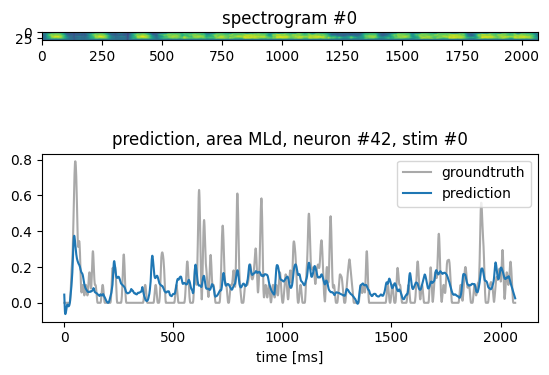

In [34]:
spectro, responses, nrn_mask = dataset[0]
spectro = spectro.unsqueeze(0).to(device) # add batch dimension: (1, F, T) --> (B, 1, F, T)
pred = net(spectro)  # (B, N, 1, T)
psth = responses.mean(dim=1)  # average over repeats to get the psth: (N, R, T) --> (N, T)


import matplotlib.pyplot as plt
%matplotlib inline
plt.ion()

plt.figure()
plt.subplot(211)
plt.title("spectrogram #0")
plt.imshow(spectro[0, 0].cpu())
plt.subplot(212)
plt.title(f"prediction, area {area}, neuron #{neuron_index}, stim #0")
plt.plot(psth[0].cpu(), label='groundtruth', color='darkgray')
plt.plot(pred[0, 0].detach().cpu(), label='prediction')
plt.xlabel("time [ms]")
plt.legend()
plt.show()

Looking nice !